## Set up Gurobipy
---

In [26]:
# First you can check, whether the required packages are already installed
# (if not, you'll receive a warning)
%pip show gurobipy
%pip show matplotlib
%pip show numpy
%pip show pandas

Name: gurobipy
Version: 13.0.2
Summary: Python interface to Gurobi
Home-page: https://www.gurobi.com
Author: Gurobi Optimization, LLC
Author-email: 
License: Proprietary
Location: C:\Users\Frede\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages
Requires: 
Required-by: 
Note: you may need to restart the kernel to use updated packages.
Name: matplotlib
Version: 3.10.9
Summary: Python plotting package
Home-page: 
Author: John D. Hunter, Michael Droettboom
Author-email: Unknown <matplotlib-users@python.org>
License: License agreement for matplotlib versions 1.3.0 and later

 1. This LICENSE AGREEMENT is between the Matplotlib Development Team
 ("MDT"), and the Individual or Organization ("Licensee") accessing and
 otherwise using matplotlib software in source or binary form and its
 associated documentation.

 2. Subject to the terms and conditions of this License Agreement, MDT
 hereby grants Licensee a nonexclusive

In [27]:
#%pip install gurobipy
#%pip install matplotlib
#%pip install numpy
#%pip install pandas

Import them into this notebook

In [28]:
import gurobipy as gp 
from gurobipy import GRB
from gurobipy import *  # imports everything from gurobipy without alias
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Budget-Constrained SALBP-2 with Human, Cobot & Humanoid
-----------------------------------------

*Budget-constrained extension of SALBP-2: each task can be performed by a **Human**, **Cobot** or **Humanoid** resource with a resource-dependent time and cost. We minimize the cycle time $C$ under a hard investment budget $B$.*

**Idea (presentation #2):** Each task can be performed by a different **resource type** $r \in \{$Human, Cobot, Industrial, Humanoid$\}$ with a resource-dependent processing time $t_{ir}$ and cost. We minimize the cycle time $C$ subject to a hard **investment budget** $B$.

### New sets / parameters
$r \in \{$Human, Cobot, Industrial, Humanoid$\}$ — resource types &nbsp;&nbsp; $t_{ir}$ — time of task $i$ with resource $r$ &nbsp;&nbsp; $H$ — horizon (h/yr) &nbsp;&nbsp; $B$ — budget &nbsp;&nbsp; $K_r = \text{invest}_r + \text{operating}_r \cdot H$

### New decision variables
$Y_{kr}=1$ if station $k$ is equipped with resource $r$ &nbsp;&nbsp; $S_{ikr}=1$ if task $i$ runs at station $k$ using resource $r$

### Objective &amp; constraints
$\min\ C$
1. $\sum_{k}\sum_{r} S_{ikr}=1\ \ \forall i$ &nbsp; (each task once)
2. $\sum_{k}\sum_{r} S_{ikr}\,k \le \sum_{k}\sum_{r} S_{jkr}\,k\ \ \forall (i,j)\in P$ &nbsp; (precedence)
3. $\sum_{i}\sum_{r} S_{ikr}\,t_{ir} \le C\ \ \forall k$ &nbsp; (cycle time)
4. $\sum_{r} Y_{kr}\le 1\ \ \forall k$ &nbsp; (at most one resource per station; empty stations allowed)
5. $S_{ikr} \le Y_{kr}\ \ \forall i,k,r$ &nbsp; (coupling)
6. $\sum_{k}\sum_{r} K_r Y_{kr} \le B$ &nbsp; (budget)


### Sets
---

In [29]:
Operations = list(range(1,16))          # 15 operations
Stations   = list(range(1,9))           # 8 stations (upper bound; empty stations allowed)
Resources  = ["Human", "Cobot", "Industrial", "Humanoid"]

N, M, R = len(Operations), len(Stations), len(Resources)

# Realistic simplified car final-assembly operations (one line segment)
OpNames = [
    "Underbody bolting",             #  1
    "Exhaust system mounting",       #  2
    "Suspension & axle",             #  3
    "Wheel mounting & torque",       #  4
    "Brake line / ABS connection",   #  5
    "Windshield & glass bonding",    #  6
    "Door hinging & alignment",      #  7
    "Wiring harness routing",        #  8
    "Cockpit / dashboard",           #  9
    "Center console & infotainment", # 10
    "Seat installation",             # 11
    "Interior trim & clips",         # 12
    "HV battery install & connect",  # 13
    "Fluid filling",                 # 14
    "Final inspection & test",       # 15
]

# Precedence (i before j): assembly sequence, final inspection last
PrecRelations = [
    [1,2],[1,3],[3,4],[1,13],
    [3,5],
    [6,9],[7,12],
    [8,9],[8,10],[8,12],
    [9,10],[9,11],
    [2,15],[4,15],[5,15],[6,15],[10,15],[11,15],[12,15],[13,15],[14,15],
]

### Processing times & eligibility  (realistic car final-assembly scenario)
Each operation can be performed by up to four resource types. **Cobots** collaborate with humans (light, precise, safe) but have limited payload and no fine dexterity. **Industrial robots** work standalone in a safety cell (fast, heavy, precise on rigid repetitive tasks) but cannot handle deformable parts, judgement or human-shared space. **Humanoids** are the most flexible machines. **Humans** are best on delicate/deformable parts and are the only resource for final inspection.

`t[i][r]` is the processing time in minutes; a value of `BIG` (99) marks a combination that is not used, and the eligibility matrix `elig[i][r]` forbids it explicitly. Columns follow `Resources = [Human, Cobot, Industrial, Humanoid]`.

In [30]:
BIG = 99.0   # sentinel time for ineligible combinations (also forbidden by elig)

#        Human  Cobot  Industrial  Humanoid              # minutes
t = [
    [ 5.5,  4.5,  3.5,  4.0],   #  1 Underbody bolting             (rigid, overhead, repetitive)
    [ 7.0,  BIG,  3.8,  4.5],   #  2 Exhaust system mounting       (heavy -> not cobot)
    [ 7.4,  BIG,  4.0,  5.0],   #  3 Suspension & axle             (high payload)
    [ 6.5,  BIG,  3.5,  4.5],   #  4 Wheel mounting & torque       (heavy, precise torque)
    [ 4.5,  3.5,  BIG,  4.0],   #  5 Brake line / ABS connection   (precise + tight -> cobot fastest)
    [ 6.0,  4.5,  3.5,  4.0],   #  6 Windshield & glass bonding    (precise bead + heavy glass)
    [ 6.0,  BIG,  4.0,  4.5],   #  7 Door hinging & alignment      (heavy, precise)
    [ 4.0,  BIG,  BIG,  5.0],   #  8 Wiring harness routing        (deformable, fine)
    [ 6.5,  BIG,  BIG,  5.0],   #  9 Cockpit / dashboard           (bulky, confined reach)
    [ 4.0,  3.5,  BIG,  3.8],   # 10 Center console & infotainment (light + connectors -> cobot fastest)
    [ 5.0,  BIG,  3.5,  4.0],   # 11 Seat installation            (heavy, repetitive)
    [ 4.5,  BIG,  BIG,  5.5],   # 12 Interior trim & clips        (fiddly, deformable clips)
    [ 5.5,  BIG,  4.0,  4.5],   # 13 HV battery install & connect (heavy + HV + precise)
    [ 3.5,  3.0,  3.0,  3.0],   # 14 Fluid filling                (standard, clean)
    [ 3.0,  BIG,  BIG,  BIG],   # 15 Final inspection & test      (judgement -> human only)
]

# Eligibility elig[i][r] = 1 if resource r can perform operation i, else 0
#        Human  Cobot  Industrial  Humanoid
elig = [
    [ 1,  1,  1,  1],   #  1 Underbody bolting
    [ 1,  0,  1,  1],   #  2 Exhaust mounting        (heavy: no cobot)
    [ 1,  0,  1,  1],   #  3 Suspension & axle       (heavy: no cobot)
    [ 1,  0,  1,  1],   #  4 Wheel mounting          (heavy: no cobot)
    [ 1,  1,  0,  1],   #  5 Brake line / ABS        (fine/tight: no industrial)
    [ 1,  1,  1,  1],   #  6 Windshield bonding
    [ 1,  0,  1,  1],   #  7 Door hinging            (heavy: no cobot)
    [ 1,  0,  0,  1],   #  8 Wiring harness          (deformable: human/humanoid only)
    [ 1,  0,  0,  1],   #  9 Cockpit / dashboard     (reach: human/humanoid only)
    [ 1,  1,  0,  1],   # 10 Center console          (light + connectors: no industrial)
    [ 1,  0,  1,  1],   # 11 Seat installation       (heavy: no cobot)
    [ 1,  0,  0,  1],   # 12 Interior trim & clips   (deformable: human/humanoid only)
    [ 1,  0,  1,  1],   # 13 HV battery              (heavy: no cobot)
    [ 1,  1,  1,  1],   # 14 Fluid filling
    [ 1,  0,  0,  0],   # 15 Final inspection        (human judgement only)
]

assert len(t) == N and all(len(row) == R for row in t), "t must be N x R."
assert len(elig) == N and all(len(row) == R for row in elig), "elig must be N x R."

### Cost parameters & budget  (realistic 2025/26 figures)
$K_r = \text{invest}_r + \text{operating}_r \cdot H$

In [31]:
# Cost parameters (every number traced to a source; see Quellen_Datengrundlage.xlsx)
H = 4000                                    # planning horizon (h/year, ~1 shift)

# --- Acquisition / investment [EUR] (sourced) ---
investment = {"Human": 0, "Cobot": 75000, "Industrial": 120000, "Humanoid": 150000}
#   Human     : no capital cost (labour only)
#   Cobot     : high-end / integrated cobot system (~75k); UR-class + integration [Standard Bots 2026; Barravecchia 2023]
#   Industrial: deployed 6-axis cell incl. tooling + safety (80-400k$ range) [Standard Bots / HowToRobot 2024/26]
#   Humanoid  : upper bound of Goldman Sachs manufacturing-cost range (~150k$), still the most expensive resource

# --- Operating cost per hour is DERIVED, not assumed ---
#   operating = own wage + supervision + energy + maintenance
#   supervision: a cobot is not autonomous -> one supervising worker is shared over 3 cobots (1:3),
#                so a cobot carries 1/6 of a human wage per hour.
wage        = {"Human": 45, "Cobot": 0, "Industrial": 0, "Humanoid": 0}          # Human: Eurostat lc_lci_lev (DE ~45)
human_wage  = 45                                                                 # supervising worker wage (EUR/h)
supervision = {"Human": 0.0, "Cobot": 1/6, "Industrial": 0.0, "Humanoid": 0.0}  # 1 supervising human per 3 cobots
power_kW    = {"Human": 0.0, "Cobot": 0.35, "Industrial": 0.7, "Humanoid": 1.0} # robot power = rough estimates
elec_price  = 0.20                                             # EUR/kWh industrial, Eurostat nrg_pc_205 (DE 2024)
maint_rate  = 0.10                                            # 10%/yr of investment (robot TCO literature, 5-10%)

operating = {r: wage[r] + supervision[r]*human_wage + power_kW[r]*elec_price + maint_rate*investment[r]/H
             for r in Resources}
# -> Human 45.0 ; Cobot ~11.32 (incl. 7.5 supervision) ; Industrial ~6.14 ; Humanoid ~7.70  EUR/h

# K(r) = investment + operating * H   (first-year total cost of ownership)
#  -> Human 90,000 < Cobot ~97,640 < Industrial ~132,280 < Humanoid ~165,400 EUR
Kcost = [investment[r] + operating[r]*H for r in Resources]
print("operating(EUR/h):", {r: round(operating[r],2) for r in Resources})
print("K(r):", dict(zip(Resources, [round(k) for k in Kcost])))

B = 1200000       # high budget so the utilization plot uses all four resource types

operating(EUR/h): {'Human': 45.0, 'Cobot': 9.45, 'Industrial': 3.14, 'Humanoid': 3.95}
K(r): {'Human': 180000, 'Cobot': 112780, 'Industrial': 132560, 'Humanoid': 165800}


### Model as a function `build_and_solve(B)`
---
Wrapping the model in a function lets us re-solve for many budget levels to trace the time-cost frontier.

In [32]:
def build_and_solve(B, silent=True):
    m = gp.Model("BudgetSALBP2")
    m.setParam("OutputFlag", 0)
    m.setParam("MIPGap", 0)

    # --- decision variables ---
    S = m.addVars(N, M, R, vtype=GRB.BINARY, name="S")   # task i at station k on resource r
    Y = m.addVars(M, R,    vtype=GRB.BINARY, name="Y")   # station k equipped with resource r
    C = m.addVar(lb=0, name="C")
    symBreak = m.addVar(lb=0, name="symBreak")

    # (1) each task assigned exactly once (any station, any resource)
    m.addConstrs((quicksum(S[i,k,r] for k in range(M) for r in range(R)) == 1
                  for i in range(N)), name="assign")

    # (2) precedence (via station index)
    m.addConstrs((quicksum(S[i,k,r]*k for k in range(M) for r in range(R))
                  <= quicksum(S[j,k,r]*k for k in range(M) for r in range(R))
                  for i in range(N) for j in range(N) if [i+1,j+1] in PrecRelations),
                 name="prec")

    # (3) cycle time per station (resource-dependent time)
    m.addConstrs((quicksum(S[i,k,r]*t[i][r] for i in range(N) for r in range(R)) <= C
                  for k in range(M)), name="cycle")

    # (4) at most one resource type per station (a station may stay empty and unpaid)
    m.addConstrs((quicksum(Y[k,r] for r in range(R)) <= 1 for k in range(M)), name="oneRes")

    # (5) coupling: a task uses resource r only if the station is equipped with it
    m.addConstrs((S[i,k,r] <= Y[k,r]
                  for i in range(N) for k in range(M) for r in range(R)), name="couple")

    # (6) budget
    m.addConstr(quicksum(Kcost[r]*Y[k,r] for k in range(M) for r in range(R)) <= B, name="budget")

    # eligibility: resource r may perform task i only if elig[i][r] == 1
    m.addConstrs((S[i,k,r] <= elig[i][r]
                  for i in range(N) for k in range(M) for r in range(R)), name="elig")

    # symmetry breaking
    m.addConstr(symBreak >= quicksum(S[i,k,r]*k*(0.1**(i+1))
                for i in range(N) for k in range(M) for r in range(R)), name="sym")

    total_cost = quicksum(Kcost[r]*Y[k,r] for k in range(M) for r in range(R))

    # --- Stage 1: minimise the cycle time ---
    m.setObjective(C + symBreak, GRB.MINIMIZE)
    m.optimize()
    if m.status != GRB.OPTIMAL:
        return None
    Cstar = C.X

    # --- Stage 2: among all solutions with C = C*, minimise total resource cost ---
    #     -> every reported configuration is Pareto-efficient (no cheaper way to reach C*)
    m.addConstr(C <= Cstar + 1e-4, name="fixC")
    m.setObjective(total_cost, GRB.MINIMIZE)
    m.optimize()
    if m.status != GRB.OPTIMAL:
        return None

    cost = sum(Kcost[r]*round(Y[k,r].X) for k in range(M) for r in range(R))
    return m, S, Y, C, cost

### Single run & solution
---

In [33]:
res = build_and_solve(B)
if res is None:
    print("No solution (budget too small?)")
else:
    m, S, Y, C, cost = res
    used = sum(1 for k in range(M) for r in range(R) if Y[k,r].X > 0.5)
    print(f"Cycle Time C: {C.x:.2f}   |   used budget: {cost} EUR   |   stations used: {used}/{M}   (B={B})")
    for k in range(M):
        eq = [r for r in range(R) if Y[k,r].X > 0.5]
        if not eq:
            continue                      # empty station (allowed, not paid)
        rk  = Resources[eq[0]]
        ops = [i+1 for i in range(N) for r in range(R) if S[i,k,r].X > 0.5]
        print(f"  Station {k+1} [{rk:10}] -> operations {ops}")

Cycle Time C: 7.50   |   used budget: 1168820.0 EUR   |   stations used: 8/8   (B=1200000)
  Station 1 [Industrial] -> operations [1, 2]
  Station 2 [Industrial] -> operations [3, 4]
  Station 3 [Industrial] -> operations [6, 7]
  Station 4 [Human     ] -> operations [8, 14]
  Station 5 [Humanoid  ] -> operations [9]
  Station 6 [Cobot     ] -> operations [5, 10]
  Station 7 [Industrial] -> operations [11, 13]
  Station 8 [Human     ] -> operations [12, 15]


### Time-Cost Frontier (sweep the budget)
---
This is the central result of the study (cf. Paper A): how much cycle time is gained per extra EUR of budget.

B=   95000:  infeasible
B=  200000:  C=78.90  used=180000.0
B=  350000:  C=31.50  used=312560.0
B=  520000:  C=21.00  used=478360.0
B=  700000:  C=15.00  used=610920.0
B=  900000:  C=11.00  used=856260.0
B= 1150000:  C=8.50  used=1149040.0
B= 1400000:  C=7.50  used=1168820.0


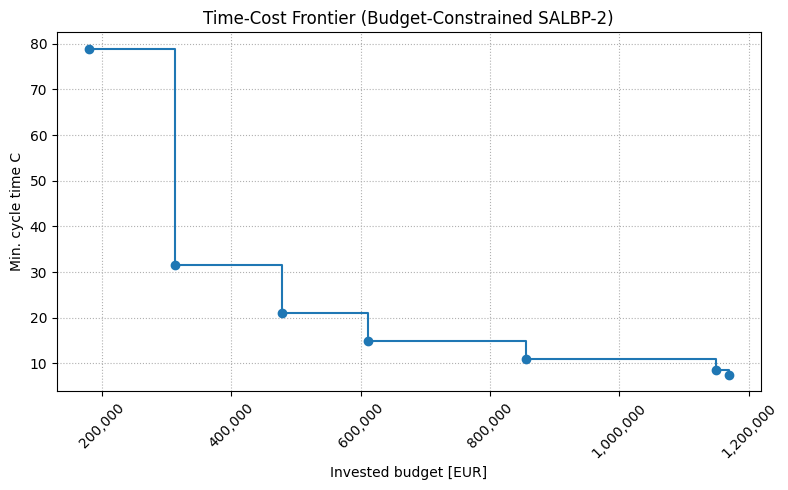

In [34]:
# With (4) <= 1, only equipped stations are paid. Everything can fit on one Human station (~90k EUR),
# so low budgets are feasible; more budget buys more stations + faster resources -> lower cycle time.
budgets = [95000, 200000, 350000, 520000, 700000, 900000, 1150000, 1400000]
front = []
for Bi in budgets:
    r = build_and_solve(Bi)
    if r:
        front.append((r[4], r[3].x))          # (used budget, C)
    print(f"B={Bi:>8}:  " + (f"C={r[3].x:.2f}  used={r[4]}" if r else "infeasible"))

if front:
    xs, ys = zip(*front)
    fig, ax = plt.subplots(figsize=(8,5))
    ax.step(xs, ys, where="post", marker="o")
    ax.set_xlabel("Invested budget [EUR]"); ax.set_ylabel("Min. cycle time C")
    ax.set_title("Time-Cost Frontier (Budget-Constrained SALBP-2)")
    ax.ticklabel_format(style="plain", axis="x")   # no 1e6 offset
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v):,}"))
    plt.xticks(rotation=45)
    ax.grid(True, linestyle=":")
    plt.tight_layout(); plt.show()

### Station utilization by resource
---

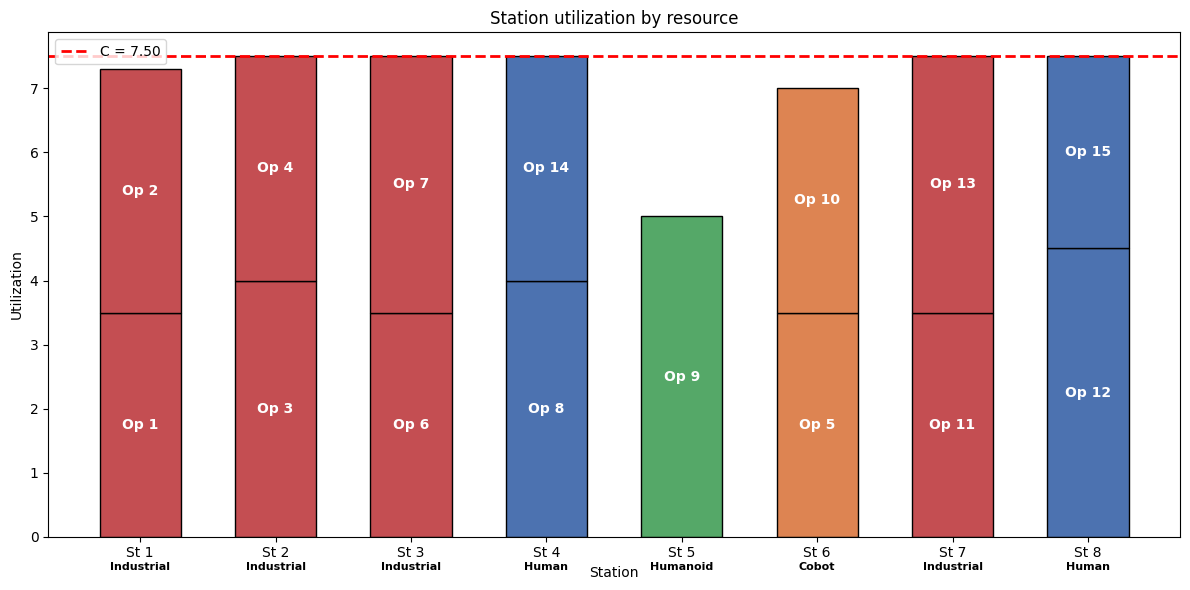

In [35]:
res = build_and_solve(B)
if res:
    m, S, Y, C, cost = res
    rescol = {"Human":"#4C72B0", "Cobot":"#DD8452", "Industrial":"#C44E52", "Humanoid":"#55A868"}
    fig, ax = plt.subplots(figsize=(12,6)); bottoms = {k:0.0 for k in range(M)}
    for k in range(M):
        eq = [r for r in range(R) if Y[k,r].X > 0.5]
        if not eq:
            continue                      # empty station -> nothing to draw
        rk = Resources[eq[0]]
        for i in range(N):
            for r in range(R):
                if S[i,k,r].X > 0.5:
                    d = t[i][r]
                    ax.bar(k, d, bottom=bottoms[k], width=0.6, color=rescol[rk], edgecolor='black')
                    ax.text(k, bottoms[k]+d/2, f'Op {i+1}', ha='center', va='center', color='white', fontweight='bold')
                    bottoms[k] += d
        ax.text(k, -0.4, rk, ha='center', va='top', fontsize=8, fontweight='bold')
    ax.axhline(C.x, color='red', ls='--', lw=2, label=f'C = {C.x:.2f}')
    ax.set_xticks(range(M)); ax.set_xticklabels([f'St {k+1}' for k in range(M)])
    ax.set_xlabel('Station'); ax.set_ylabel('Utilization'); ax.legend()
    ax.set_title('Station utilization by resource'); plt.tight_layout(); plt.show()
else:
    print("No solution to visualize.")

### Notes & data sources
**Cost basis (2025/26), four resource types:**
- Human: German labour cost ~45 EUR/h (Eurostat lc_lci_lev), no capital cost.
- Cobot: ~75,000 EUR high-end / integrated cobot system (Standard Bots 2026; cost model Barravecchia 2023).
- Industrial robot: ~120,000 EUR deployed 6-axis cell incl. tooling and safety (Standard Bots / HowToRobot; range 80-400k$).
- Humanoid: ~150,000 EUR, upper bound of the Goldman Sachs manufacturing-cost range (30-150k$).
- Operating cost per hour is derived: energy (power x 0.20 EUR/kWh, Eurostat nrg_pc_205) + maintenance (10% of capex/yr, robot TCO literature); Human = wage.
- Resulting annual K(r): **Cobot ~82.6k < Human 90k < Industrial ~132.3k < Humanoid ~165.4k EUR**.

**Resource logic:** cobots collaborate with humans (safe, precise, light); industrial robots work standalone in a cell (fast, heavy, rigid tasks) but cannot handle deformable parts or judgement; humanoids are the most flexible machines; humans are best on delicate tasks and the only resource for inspection. Impossible combinations are forbidden by the eligibility matrix `elig`.

**Modelling switches:**
- Constraint (4) `== 1` forces every station to be equipped (and paid). Use `<= 1` to allow free empty stations (lowers the feasible budget).
- Ineligible combinations use the sentinel time `BIG = 99` and are also fixed to zero via `S[i,k,r] <= elig[i][r]`.


## Extended visualisations
---
The following graphs are adapted from **Visualisation.ipynb** to the parameters of *this*
notebook (resources `Human/Cobot/Industrial/Humanoid`, times `t` with eligibility `elig`,
costs `investment`/`operating`/`Kcost`).

A small adapter `solve_extended(B, H, allowed)` is defined that returns a **dict** with the
solution (two-stage: first minimum cycle time `C`, then the cheapest equipment mix among
all optima). All graphs read from this dict.

In [36]:
# ===================================================================
# Adapter: solve_extended(...) auf den Parametern DIESES Notebooks.
# Konsistent mit dem Hauptmodell: <= 1 Ressource pro Station (leere
# stations sind kostenlos) und Betriebskosten inkl. Cobot-Aufsicht (1:6).
# ===================================================================
from matplotlib.patches import Patch

col = {"Human": "#4C72B0", "Cobot": "#DD8452", "Industrial": "#C44E52", "Humanoid": "#55A868"}

t_r = [[t[i][r] if elig[i][r] else None for r in range(R)] for i in range(N)]

# --- Kosten als Funktion des Planungshorizonts H -------------------------------
# K(r,H) = investment*(1+maint_rate) + (wage + supervision*human_wage + power_kW*elec_price) * H
#   -> reproduziert Kcost exakt bei H = 2000 (inkl. Cobot-Aufsicht)
oper_h    = {r: wage[r] + supervision[r]*human_wage + power_kW[r]*elec_price for r in Resources}
base_cost = {r: investment[r]*(1 + maint_rate) for r in Resources}
def K_of(Hh):
    return [base_cost[Resources[r]] + oper_h[Resources[r]]*Hh for r in range(R)]

# guenstigste zulaessige Loesung: EINE Human-Station reicht (Human kann jede Operation)
B_min = K_of(H)[Resources.index("Human")]

def mixlabel(cnt):
    return "+".join(f"{n}{s}" for n, s in zip(cnt, ["Hm", "Cb", "In", "Ro"]) if n > 0)

def solve_extended(Bbudget, Hh=H, allowed=None):
    """Budget-constrained SALBP-2, two-stage (min C, then cheapest mix)."""
    allowed = set(range(R)) if allowed is None else set(allowed)
    Kr = K_of(Hh)

    mE = gp.Model("BudgetSALBP2_viz")
    mE.setParam("OutputFlag", 0); mE.setParam("MIPGap", 1e-3); mE.setParam("TimeLimit", 20)
    Sv = mE.addVars(N, M, R, vtype=GRB.BINARY, name="S")
    Yv = mE.addVars(M, R,    vtype=GRB.BINARY, name="Y")
    Cv = mE.addVar(lb=0, name="C")
    totalCost = quicksum(Kr[r]*Yv[k,r] for k in range(M) for r in range(R))

    mE.addConstrs((quicksum(Sv[i,k,r] for k in range(M) for r in range(R)) == 1
                   for i in range(N)), name="assign")
    mE.addConstrs((quicksum(Yv[k,r] for r in range(R)) <= 1 for k in range(M)), name="oneRes")
    # Symmetriebrechung: benutzte Stationen links packen (keine Luecken) -> viel schneller
    mE.addConstrs((quicksum(Yv[k+1,r] for r in range(R)) <= quicksum(Yv[k,r] for r in range(R))
                   for k in range(M-1)), name="pack")
    mE.addConstrs((Sv[i,k,r] <= Yv[k,r]
                   for i in range(N) for k in range(M) for r in range(R)), name="couple")
    mE.addConstrs((Sv[i,k,r] == 0
                   for i in range(N) for r in range(R) if not elig[i][r]
                   for k in range(M)), name="elig")
    mE.addConstrs((quicksum(Sv[i,k,r]*t[i][r] for i in range(N) for r in range(R) if elig[i][r]) <= Cv
                   for k in range(M)), name="cycle")
    mE.addConstrs((quicksum(Sv[i,k,r]*k for k in range(M) for r in range(R)) <=
                   quicksum(Sv[j,k,r]*k for k in range(M) for r in range(R))
                   for i in range(N) for j in range(N) if [i+1,j+1] in PrecRelations), name="prec")
    mE.addConstr(totalCost <= Bbudget, name="budget")
    for r in range(R):
        if r not in allowed:
            mE.addConstrs((Yv[k,r] == 0 for k in range(M)), name=f"forbid{r}")

    # Stufe 1: minimale Taktzeit
    mE.setObjective(Cv, GRB.MINIMIZE); mE.optimize()
    if mE.SolCount == 0:
        return {"B": Bbudget, "status": mE.status, "C": None}
    C_opt = Cv.x
    # Stufe 2: unter allen Optima der guenstigste Mix
    mE.addConstr(Cv <= C_opt + 1e-6)
    mE.setObjective(totalCost, GRB.MINIMIZE); mE.optimize()

    # leere Stationen (Yv == 0) sind erlaubt -> None
    resource_of = {k: next((r for r in range(R) if Yv[k,r].x > 0.5), None) for k in range(M)}
    equip  = {k: (Resources[resource_of[k]] if resource_of[k] is not None else "") for k in range(M)}
    assign = {k: [i+1 for i in range(N) for r in range(R) if Sv[i,k,r].x > 0.5] for k in range(M)}
    counts = [sum(1 for k in range(M) if resource_of[k] == r) for r in range(R)]
    cost   = int(sum(Kr[r]*round(Yv[k,r].x) for k in range(M) for r in range(R)))
    return {"B": Bbudget, "status": int(mE.status), "C": round(C_opt, 2),
            "equip": equip, "assign": assign, "resource_of": resource_of,
            "counts": counts, "cost": cost, "nHumanoid": counts[Resources.index("Humanoid")]}

B_example = max(int(B), int(B_min))
sol = solve_extended(B_example)
if sol["C"] is None:
    print(f"Example B = {B_example:,} EUR  ->  no solution (budget too small?)")
else:
    print(f"Example B = {B_example:,} EUR  ->  C = {sol['C']},  "
          f"mix = {mixlabel(sol['counts'])},  cost = {sol['cost']:,} EUR")

Example B = 1,200,000 EUR  ->  C = 7.5,  mix = 2Hm+1Cb+4In+1Ro,  cost = 1,168,820 EUR


### 1 · Resource-dependent processing times $t(i,r)$
---

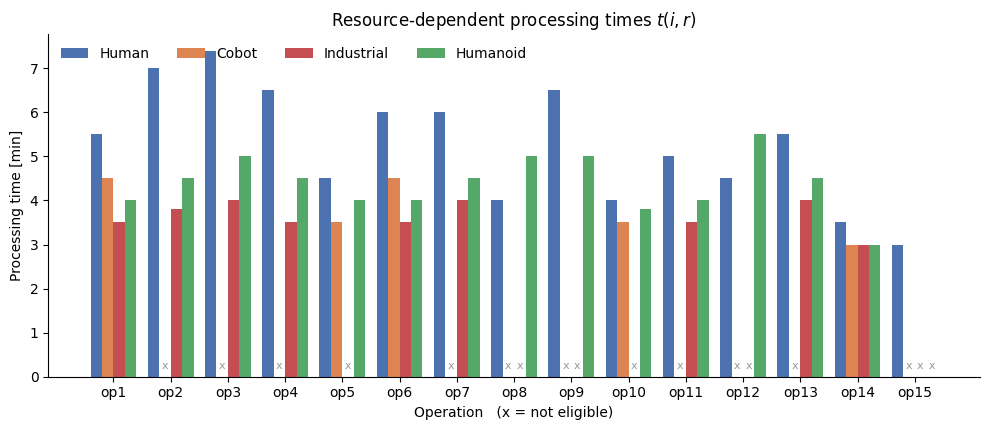

In [37]:
fig, ax = plt.subplots(figsize=(10, 4.4))
x = np.arange(N); w = 0.2
for r in range(R):
    vals = [t_r[i][r] if elig[i][r] else 0 for i in range(N)]
    ax.bar(x + (r - 1.5)*w, vals, w, label=Resources[r], color=col[Resources[r]])
    for i in range(N):
        if not elig[i][r]:                       # nicht geeignete Kombinationen markieren
            ax.text(x[i] + (r - 1.5)*w, 0.12, "x", ha="center", va="bottom", fontsize=8, color="#999")
ax.set_xticks(x); ax.set_xticklabels([f"op{i+1}" for i in range(N)])
ax.set_xlabel("Operation   (x = not eligible)"); ax.set_ylabel("Processing time [min]")
ax.set_title("Resource-dependent processing times $t(i,r)$")
ax.legend(frameon=False, ncol=4, loc="upper left")
for s in ["top", "right"]: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

### 1b · Processing-time table $t(i,r)$ (heatmap style)
---
Dieselben Zeiten als getönte Tabelle: pro Operation ist die **schnellste geeignete** Ressource hervorgehoben (voller Farbton, fett, umrahmt); nicht geeignete Kombinationen sind schraffiert mit „—".

In [ ]:
from matplotlib.patches import Rectangle
from matplotlib.colors import to_rgb

def _tint(hexcol, f=0.22):                     # Farbton Richtung Weiss aufhellen
    r, g, b = to_rgb(hexcol)
    return (1-f + f*r, 1-f + f*g, 1-f + f*b)

fig, ax = plt.subplots(figsize=(9.2, 5.2))
cw = ch = 1.0; gap = 0.06; x0 = 0.0
for i in range(N):
    fastest_time = min(t[i][r] for r in range(R) if elig[i][r])   # schnellste geeignete Zeit
    y = -i
    for r in range(R):
        x = x0 + r*cw; rc = Resources[r]
        if not elig[i][r]:
            ax.add_patch(Rectangle((x, y-ch/2+gap/2), cw-gap, ch-gap, facecolor="#f2f2f2",
                                    edgecolor="#dddddd", hatch="///", lw=0.8))
            ax.text(x+cw/2-gap/2, y, "—", ha="center", va="center", color="#bbbbbb", fontsize=11)
        elif t[i][r] == fastest_time:                          # ALLE Optima umrahmen (nicht nur das erste)
            ax.add_patch(Rectangle((x, y-ch/2+gap/2), cw-gap, ch-gap, facecolor=col[rc],
                                    edgecolor="#222222", lw=1.8))
            ax.text(x+cw/2-gap/2, y, f"{t[i][r]:.2f}", ha="center", va="center",
                    color="white", fontsize=11, fontweight="bold")
        else:
            ax.add_patch(Rectangle((x, y-ch/2+gap/2), cw-gap, ch-gap, facecolor=_tint(col[rc]),
                                    edgecolor="white", lw=1.0))
            ax.text(x+cw/2-gap/2, y, f"{t[i][r]:.2f}", ha="center", va="center", color="#333333", fontsize=11)
    ax.text(x0-0.45, y, OpNames[i], ha="right", va="center", fontsize=10, color="#222222")
    ax.text(x0-0.18, y, str(i+1), ha="right", va="center", fontsize=10, fontweight="bold", color="#222222")

yh = 1.0                                        # Kopfzeile
for r in range(R):
    x = x0 + r*cw
    ax.add_patch(Rectangle((x, yh-ch/2+gap/2), cw-gap, ch-gap, facecolor=col[Resources[r]],
                           edgecolor="white", lw=1.0))
    ax.text(x+cw/2-gap/2, yh, Resources[r], ha="center", va="center",
            color="white", fontsize=10.5, fontweight="bold")

ax.text(x0-0.45, yh+0.15, "Processing time  $t(i,r)$  [min]", ha="right", va="bottom",
        fontsize=11, fontstyle="italic", color="#555555")
ax.set_xlim(x0-5.1, x0+R*cw+0.1); ax.set_ylim(-N-0.6, yh+0.7); ax.axis("off")
plt.tight_layout()
# fig.savefig("pom_lukas_zeitentabelle.png", dpi=150, bbox_inches="tight")   # optional als PNG speichern
plt.show()

### 2 · Resource assignment & station loads
---

In [ ]:
assert sol["C"] is not None, "No solution for B_example - increase budget."
fig, ax = plt.subplots(figsize=(9.5, 4.6))
for k in range(M):
    r = sol["resource_of"][k]
    if r is None:
        continue
    left = 0
    for op in sol["assign"][k]:
        wdt = t[op-1][r]
        ax.barh(k, wdt, left=left, color=col[Resources[r]], edgecolor="white", height=0.62)
        ax.text(left + wdt/2, k, str(op), ha="center", va="center", color="white", fontsize=9, fontweight="bold")
        left += wdt
    # Ressourcen-Label in fester Spalte rechts HINTER der gestrichelten C-Linie
    ax.text(sol["C"] + 0.15, k, sol["equip"][k], va="center", ha="left",
            color=col[Resources[r]], fontsize=9, fontweight="bold")
ax.axvline(sol["C"], ls="--", lw=1.6, color="#333")
ax.set_yticks(range(M)); ax.set_yticklabels([f"Station {k+1}" for k in range(M)])
ax.set_ylim(-0.7, M - 0.3); ax.invert_yaxis()
# C-Label nach unten auf Hoehe der x-Achsen-Zahlen, mittig unter der Linie
ax.text(sol["C"], -0.015, f"C = {sol['C']}", transform=ax.get_xaxis_transform(),
        color="#333", fontsize=9, fontweight="bold", va="top", ha="center")
ax.set_xlim(0, sol["C"]*1.42)
ax.set_xlabel("Station load  /  cycle time  [min]")
ax.set_title(f"Resource assignment & station loads   (B = {B_example:,} EUR)")
ax.legend(handles=[Patch(facecolor=col[r], label=r) for r in Resources], loc="lower right", frameon=False)
for s in ["top", "right"]: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

### 3 · Time-cost frontier
---
Das Budget wird von der günstigsten (all-Human) Linie aufwärts durchlaufen.

In [ ]:
budgets  = list(range(int(B_min), int(min(M*max(K_of(H)), 1_250_000)) + 1, 25_000))
frontier = [f for f in (solve_extended(Bi) for Bi in budgets) if f["C"] is not None]

df_frontier = pd.DataFrame({
    "Budget B [EUR]":     [f["B"] for f in frontier],
    "min. cycle time C":    [f["C"] for f in frontier],
    "Mix (Hm,Cb,In,Ro)":  [tuple(f["counts"]) for f in frontier],
    "Mix cost [EUR]":   [f["cost"] for f in frontier],
})
print(df_frontier.iloc[::4].to_string(index=False))

In [ ]:
xb = [f["B"]/1000 for f in frontier]; yc = [f["C"] for f in frontier]
fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.step(xb, yc, where="post", color="#C44E52", lw=2, zorder=2)
ax.scatter(xb, yc, color="#C44E52", s=22, zorder=3)

# Start (langsamste/guenstigste Loesung) unter dem ersten Punkt,
# Ende (schnellste/teuerste Loesung) ueber dem letzten Punkt -> Start & Ende sichtbar
ax.annotate(f"C = {yc[0]}", (xb[0], yc[0]), textcoords="offset points", xytext=(0, -12),
            ha="center", va="top", fontsize=9, fontweight="bold", color="#C44E52")
ax.annotate(f"C = {yc[-1]}", (xb[-1], yc[-1]), textcoords="offset points", xytext=(0, 12),
            ha="center", va="bottom", fontsize=9, fontweight="bold", color="#C44E52")

ax.set_xlabel("Budget  B  [k EUR]"); ax.set_ylabel("min. cycle time  C  [min]")
ax.set_title("Time-cost frontier", pad=12); ax.grid(axis="y", alpha=0.25)
ax.margins(y=0.12)
for s in ["top", "right"]: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

### 4 · Marginal benefit of budget
---
The frontier read as a staircase: how much cycle time does each expansion step buy?

                              Step  from C  to C  dC [min]  Extra cost [EUR]  dC per 100k EUR
                    1Hm -> 1Hm+1Cb    78.9  63.9      15.0            112780            13.30
                1Hm+1Cb -> 1Hm+1In    63.9  31.5      32.4             19780           163.80
            1Hm+1In -> 1Hm+1Cb+1In    31.5  27.0       4.5            112780             3.99
        1Hm+1Cb+1In -> 1Hm+1In+1Ro    27.0  21.0       6.0             53020            11.32
    1Hm+1In+1Ro -> 1Hm+1Cb+1In+1Ro    21.0  17.8       3.2            112780             2.84
    1Hm+1Cb+1In+1Ro -> 1Hm+2In+1Ro    17.8  15.0       2.8             19780            14.16
    1Hm+2In+1Ro -> 1Hm+2Cb+1In+1Ro    15.0  14.8       0.2             93000             0.22
1Hm+2Cb+1In+1Ro -> 1Hm+1Cb+2In+1Ro    14.8  13.8       1.0             19780             5.06
    1Hm+1Cb+2In+1Ro -> 1Hm+2In+2Ro    13.8  12.8       1.0             53020             1.89
    1Hm+2In+2Ro -> 1Hm+2Cb+2In+1Ro    12.8  11.5       1.3  

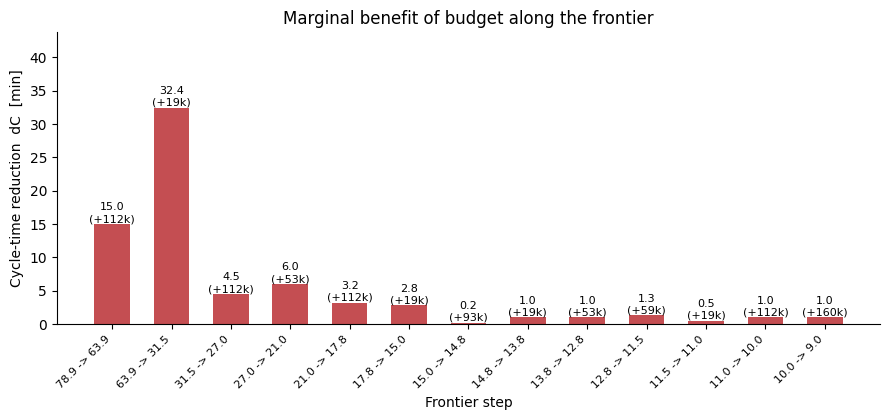

In [42]:
knees = {}
for f in frontier:
    if f["C"] not in knees: knees[f["C"]] = f
knees = sorted(knees.values(), key=lambda f: -f["C"])      # langsam/billig -> schnell/teuer

rows = []
for a, b in zip(knees[:-1], knees[1:]):
    dC, dE = round(a["C"] - b["C"], 2), b["cost"] - a["cost"]
    rows.append({"Step": f"{mixlabel(a['counts'])} -> {mixlabel(b['counts'])}",
                 "from C": a["C"], "to C": b["C"], "dC [min]": dC, "Extra cost [EUR]": dE,
                 "dC per 100k EUR": round(dC/(dE/1e5), 2) if dE else float('nan')})
df_marg = pd.DataFrame(rows); print(df_marg.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4.3))
dCs = [r["dC [min]"] for r in rows]
ax.bar(range(len(rows)), dCs, 0.6, color="#C44E52")
for j, r in enumerate(rows):
    ax.text(j, r["dC [min]"] + 0.006, f"{r['dC [min]']}\n(+{r['Extra cost [EUR]']//1000}k)",
            ha="center", va="bottom", fontsize=8)
ax.set_xticks(range(len(rows)))
ax.set_xticklabels([f"{r['from C']} -> {r['to C']}" for r in rows], rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Frontier step"); ax.set_ylabel("Cycle-time reduction  dC  [min]")
ax.set_title("Marginal benefit of budget along the frontier")
ax.set_ylim(0, (max(dCs) if dCs else 1)*1.35)
for s in ["top", "right"]: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

### 5 · Optimal resource mix along the frontier
---

In [ ]:
fig, ax = plt.subplots(figsize=(9.5, 5.2))
xk = np.arange(len(knees)); bottom = np.zeros(len(knees))
for r in range(R):
    vals = np.array([k["counts"][r] for k in knees])
    ax.bar(xk, vals, 0.62, bottom=bottom, label=Resources[r], color=col[Resources[r]], edgecolor="white")
    for j, v in enumerate(vals):
        if v > 0:
            ax.text(xk[j], bottom[j] + v/2, str(int(v)), ha="center", va="center",
                    color="white", fontweight="bold")
    bottom = bottom + vals

# Taktzeit C ueber den Balken (statt in der x-Achse)
for j in range(len(knees)):
    ax.text(xk[j], bottom[j] + 0.12, f"C = {knees[j]['C']}", ha="center", va="bottom",
            fontsize=9, fontweight="bold", color="#333")

ax.set_xticks(xk)
ax.set_xticklabels([f"{k['cost']//1000}k EUR" for k in knees], rotation=90, fontsize=8)
ax.set_xlabel("Budget along the frontier  (mix cost)")
ax.set_ylabel("# stations"); ax.set_ylim(0, M + 2.8)
ax.set_title("Optimal resource mix along the frontier", pad=10)
ax.legend(frameon=False, ncol=4, loc="upper center")
for s in ["top", "right"]: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

### 6 · Capital budgeting: role of utilisation $H$
---
$K(r,H)$ is linear in $H$; the ranking of the resources depends on the horizon.

Break-even utilisation H* (equal K over the horizon):
  Human        = Cobot        at H* =    2,204 h/year
  Human        = Industrial   at H* =    2,942 h/year
  Human        = Humanoid     at H* =    3,683 h/year
  Cobot        = Industrial   at H* =    6,662 h/year
  Cobot        = Humanoid     at H* =   11,194 h/year
  Industrial   always cheaper than Humanoid


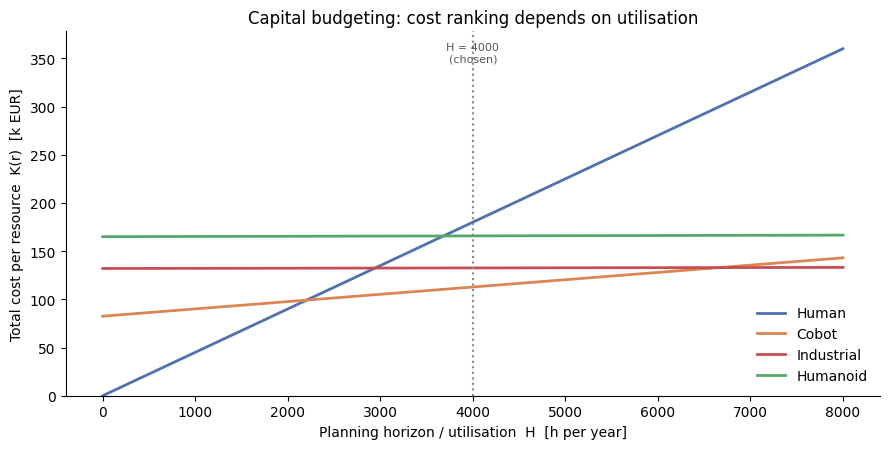

In [44]:
import itertools
print("Break-even utilisation H* (equal K over the horizon):")
for a, b in itertools.combinations(range(R), 2):
    d_base  = base_cost[Resources[b]] - base_cost[Resources[a]]
    d_slope = oper_h[Resources[a]] - oper_h[Resources[b]]
    if d_slope > 0 and d_base > 0:
        print(f"  {Resources[a]:12s} = {Resources[b]:12s} at H* = {d_base/d_slope:8,.0f} h/year")
    elif d_base >= 0 and d_slope <= 0:
        print(f"  {Resources[a]:12s} always cheaper than {Resources[b]}")

fig, ax = plt.subplots(figsize=(9, 4.6))
Hs = np.linspace(0, 8000, 200)
for r in range(R):
    ax.plot(Hs, [(base_cost[Resources[r]] + oper_h[Resources[r]]*h)/1000 for h in Hs],
            label=Resources[r], color=col[Resources[r]], lw=2)
ax.axvline(H, ls=":", color="#888")
ax.text(H, 0.97, f"H = {H}\n(chosen)", transform=ax.get_xaxis_transform(),
        fontsize=8, ha="center", va="top", color="#555")
ax.set_xlabel("Planning horizon / utilisation  H  [h per year]")
ax.set_ylabel("Total cost per resource  K(r)  [k EUR]")
ax.set_title("Capital budgeting: cost ranking depends on utilisation")
ax.legend(frameon=False, loc="lower right"); ax.set_ylim(bottom=0)
for s in ["top", "right"]: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

### 7 · Interactive: budget slider
---
Drag the **budget slider** to redraw graph 2 for an arbitrary budget (falls back to a static graph if `ipywidgets` is missing).

In [45]:
def plot_station_loads(Bbudget):
    """Graph 2, redrawn for an arbitrary budget B."""
    s = solve_extended(int(Bbudget))
    if s["C"] is None:
        print("not solvable at this budget"); return
    fig, ax = plt.subplots(figsize=(9.5, 4.6))
    for k in range(M):
        r = s["resource_of"][k]
        if r is None:
            continue
        left = 0
        for op in s["assign"][k]:
            wdt = t[op-1][r]
            ax.barh(k, wdt, left=left, color=col[Resources[r]], edgecolor="white", height=0.62)
            ax.text(left + wdt/2, k, str(op), ha="center", va="center", color="white", fontsize=9, fontweight="bold")
            left += wdt
        ax.text(left + 0.1, k, s["equip"][k], va="center", color=col[Resources[r]], fontsize=9, fontweight="bold")
    ax.axvline(s["C"], ls="--", lw=1.6, color="#333")
    ax.set_yticks(range(M)); ax.set_yticklabels([f"Station {k+1}" for k in range(M)])
    ax.set_ylim(-0.7, M - 0.3); ax.invert_yaxis()
    ax.text(s["C"], M - 0.6, f"C = {s['C']}  ", color="#333", fontsize=9, va="center", ha="right")
    ax.set_xlim(0, s["C"]*1.42)
    ax.set_xlabel("Station load  /  cycle time  [min]")
    ax.set_title(f"Line   (B = {int(Bbudget):,} EUR,  C = {s['C']},  Mix = {mixlabel(s['counts'])})")
    ax.legend(handles=[Patch(facecolor=col[r], label=r) for r in Resources], loc="lower right", frameon=False)
    for sp in ["top", "right"]: ax.spines[sp].set_visible(False)
    plt.tight_layout(); plt.show()

try:
    import ipywidgets as widgets
    widgets.interact(
        plot_station_loads,
        Bbudget=widgets.IntSlider(value=int(B_example), min=int(B_min), max=int(M*max(K_of(H))),
                                  step=15_000, description="Budget B [EUR]:", continuous_update=False,
                                  readout_format=",d", style={"description_width": "initial"},
                                  layout=widgets.Layout(width="640px")))
except ModuleNotFoundError:
    print("ipywidgets not available - static graph instead "
          "(install: pip install ipywidgets)")
    plot_station_loads(B_example)

interactive(children=(IntSlider(value=1200000, continuous_update=False, description='Budget B [EUR]:', layout=…

In [ ]:
# ============================================================================
# 7b · Budget-Slider als GIF / MP4 fuer PowerPoint
# ----------------------------------------------------------------------------
# Rendert denselben Plot wie Grafik 7 fuer viele Budget-Stufen und speichert
# daraus eine Animation. In PPT einfach per "Einfuegen -> Video/Bild" nutzen.
# ============================================================================
import io, os
from PIL import Image

# --- Budget-Stufen der Animation (Start = 1 Human-Station, Ende = teuerstes Optimum)
gif_budgets = list(range(int(B_min), int(min(M*max(K_of(H)), 1_250_000)) + 1, 50_000))

# alle Loesungen einmal vorab rechnen (Gurobi pro Frame) und feste x-Achse bestimmen,
# damit die rote Taktzeit-Linie beim "Schieben" sauber nach links wandert
sols = {Bi: solve_extended(int(Bi)) for Bi in gif_budgets}
XMAX = max(s["C"] for s in sols.values() if s["C"] is not None) * 1.12

def _render_frame(Bbudget):
    """Ein Frame = Grafik 7 fuer ein festes Budget, als PIL-Bild (feste Groesse)."""
    s = sols[Bbudget]
    fig, ax = plt.subplots(figsize=(9.5, 4.6), dpi=110)   # feste Groesse -> gleich grosse Frames
    if s["C"] is None:
        ax.text(0.5, 0.5, f"B = {int(Bbudget):,} EUR\nnot solvable",
                ha="center", va="center", fontsize=12); ax.axis("off")
    else:
        for k in range(M):
            r = s["resource_of"][k]
            if r is None:
                continue
            left = 0
            for op in s["assign"][k]:
                wdt = t[op-1][r]
                ax.barh(k, wdt, left=left, color=col[Resources[r]], edgecolor="white", height=0.62)
                ax.text(left + wdt/2, k, str(op), ha="center", va="center",
                        color="white", fontsize=9, fontweight="bold")
                left += wdt
            ax.text(left + 0.1, k, s["equip"][k], va="center",
                    color=col[Resources[r]], fontsize=9, fontweight="bold")
        ax.axvline(s["C"], ls="--", lw=1.6, color="#333")
        ax.set_yticks(range(M)); ax.set_yticklabels([f"Station {k+1}" for k in range(M)])
        ax.set_ylim(-0.7, M - 0.3); ax.invert_yaxis()
        ax.text(s["C"], M - 0.6, f"C = {s['C']}  ", color="#333", fontsize=9, va="center", ha="right")
        ax.set_xlim(0, XMAX)                              # feste Achse ueber alle Frames
        ax.set_xlabel("Station load  /  cycle time  [min]")
        ax.set_title(f"Line   (B = {int(Bbudget):,} EUR,  C = {s['C']},  Mix = {mixlabel(s['counts'])})")
        ax.legend(handles=[Patch(facecolor=col[r], label=r) for r in Resources],
                  loc="lower right", frameon=False)
        for sp in ["top", "right"]: ax.spines[sp].set_visible(False)
    fig.tight_layout()
    buf = io.BytesIO(); fig.savefig(buf, format="png"); plt.close(fig)
    buf.seek(0); return Image.open(buf).convert("RGB")

frames = [_render_frame(Bi) for Bi in gif_budgets]

# --- GIF speichern (Pillow ist immer vorhanden) -----------------------------
gif_path = "graph7_budget_slider.gif"
frames[0].save(gif_path, save_all=True, append_images=frames[1:],
               duration=500,           # ms pro Frame
               loop=0)                 # 0 = Endlosschleife
print(f"GIF gespeichert: {os.path.abspath(gif_path)}  ({len(frames)} Frames)")

# --- MP4 optional (falls imageio + ffmpeg verfuegbar) -----------------------
mp4_path = "graph7_budget_slider.mp4"
try:
    import numpy as _np
    import imageio.v2 as imageio
    imageio.mimsave(mp4_path, [_np.array(fr) for fr in frames], fps=2)
    print(f"MP4 gespeichert: {os.path.abspath(mp4_path)}")
except Exception as e:
    print(f"MP4 uebersprungen ({e}). Fuer MP4:  pip install imageio imageio-ffmpeg")

# Vorschau im Notebook
from IPython.display import Image as IPYImage
IPYImage(filename=gif_path)

In [ ]:
# ============================================================================
# 7b · Budget-Slider als GIF / MP4 fuer PowerPoint
# ----------------------------------------------------------------------------
# Rendert denselben Plot wie Grafik 7 fuer viele Budget-Stufen und speichert
# daraus eine Animation. In PPT einfach per "Einfuegen -> Video/Bild" nutzen.
# ============================================================================
import io, os
from PIL import Image

# --- Budget-Stufen der Animation (Start = 1 Human-Station, Ende = teuerstes Optimum)
gif_budgets = list(range(int(B_min), int(min(M*max(K_of(H)), 1_250_000)) + 1, 50_000))

# alle Loesungen einmal vorab rechnen (Gurobi pro Frame) und feste x-Achse bestimmen,
# damit die rote Taktzeit-Linie beim "Schieben" sauber nach links wandert
sols = {Bi: solve_extended(int(Bi)) for Bi in gif_budgets}
XMAX = max(s["C"] for s in sols.values() if s["C"] is not None) * 1.12

def _render_frame(Bbudget):
    """Ein Frame = Grafik 7 fuer ein festes Budget, als PIL-Bild (feste Groesse)."""
    s = sols[Bbudget]
    fig, ax = plt.subplots(figsize=(9.5, 4.6), dpi=110)   # feste Groesse -> gleich grosse Frames
    if s["C"] is None:
        ax.text(0.5, 0.5, f"B = {int(Bbudget):,} EUR\nnot solvable",
                ha="center", va="center", fontsize=12); ax.axis("off")
    else:
        for k in range(M):
            r = s["resource_of"][k]
            if r is None:
                continue
            left = 0
            for op in s["assign"][k]:
                wdt = t[op-1][r]
                ax.barh(k, wdt, left=left, color=col[Resources[r]], edgecolor="white", height=0.62)
                ax.text(left + wdt/2, k, str(op), ha="center", va="center",
                        color="white", fontsize=9, fontweight="bold")
                left += wdt
            ax.text(left + 0.1, k, s["equip"][k], va="center",
                    color=col[Resources[r]], fontsize=9, fontweight="bold")
        ax.axvline(s["C"], ls="--", lw=1.6, color="#333")
        ax.set_yticks(range(M)); ax.set_yticklabels([f"Station {k+1}" for k in range(M)])
        ax.set_ylim(-0.7, M - 0.3); ax.invert_yaxis()
        ax.text(s["C"], M - 0.6, f"C = {s['C']}  ", color="#333", fontsize=9, va="center", ha="right")
        ax.set_xlim(0, XMAX)                              # feste Achse ueber alle Frames
        ax.set_xlabel("Station load  /  cycle time  [min]")
        ax.set_title(f"Line   (B = {int(Bbudget):,} EUR,  C = {s['C']},  Mix = {mixlabel(s['counts'])})")
        ax.legend(handles=[Patch(facecolor=col[r], label=r) for r in Resources],
                  loc="lower right", frameon=False)
        for sp in ["top", "right"]: ax.spines[sp].set_visible(False)
    fig.tight_layout()
    buf = io.BytesIO(); fig.savefig(buf, format="png"); plt.close(fig)
    buf.seek(0); return Image.open(buf).convert("RGB")

frames = [_render_frame(Bi) for Bi in gif_budgets]

# --- GIF speichern (Pillow ist immer vorhanden) -----------------------------
gif_path = "graph7_budget_slider.gif"
frames[0].save(gif_path, save_all=True, append_images=frames[1:],
               duration=500,           # ms pro Frame
               loop=0)                 # 0 = Endlosschleife
print(f"GIF gespeichert: {os.path.abspath(gif_path)}  ({len(frames)} Frames)")

# --- MP4 optional (falls imageio + ffmpeg verfuegbar) -----------------------
mp4_path = "graph7_budget_slider.mp4"
try:
    import numpy as _np
    import imageio.v2 as imageio
    imageio.mimsave(mp4_path, [_np.array(fr) for fr in frames], fps=2)
    print(f"MP4 gespeichert: {os.path.abspath(mp4_path)}")
except Exception as e:
    print(f"MP4 uebersprungen ({e}). Fuer MP4:  pip install imageio imageio-ffmpeg")

# Vorschau im Notebook
from IPython.display import Image as IPYImage
IPYImage(filename=gif_path)

### 8 · Resource stations by budget
x-axis: budget, y-axis: number of stations per resource type (stacked). Shows from which budget how many stations of which resource are used.

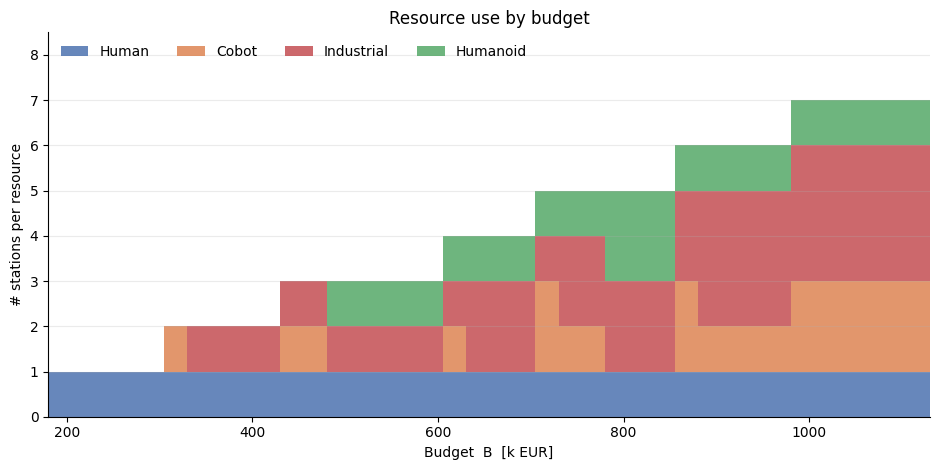

In [46]:
# ---- 8 · Resource use by budget (gestapelt) --------------------------------
xb8 = np.array([f["B"]/1000 for f in frontier])
counts_by_r = [[f["counts"][r] for f in frontier] for r in range(R)]

fig, ax = plt.subplots(figsize=(9.5, 4.8))
bottom = np.zeros(len(xb8))
for r in range(R):
    vals = np.array(counts_by_r[r])
    ax.fill_between(xb8, bottom, bottom + vals, step="post",
                    color=col[Resources[r]], alpha=0.85, label=Resources[r], linewidth=0)
    bottom = bottom + vals
ax.set_xlabel("Budget  B  [k EUR]")
ax.set_ylabel("# stations per resource")
ax.set_title("Resource use by budget")
ax.set_ylim(0, M + 0.5); ax.margins(x=0)
ax.legend(frameon=False, ncol=4, loc="upper left")
ax.grid(axis="y", alpha=0.25)
for s in ["top", "right"]: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

### 9 · At which budget is a humanoid used?
Lists exactly the budget points where the optimal mix contains at least one humanoid, plus a finer search to narrow down the threshold.

In [ ]:
# ============================================================================
# Resource mix as a function of utilisation H  (budget fixed)
# ============================================================================
B_fix  = int(B_example)                    # fixed budget (adjust if needed)
H_grid = list(range(0, 8001, 250))         # hours per year  (0 .. 8000)
res_H  = [solve_extended(B_fix, Hh=Hh) for Hh in H_grid]

xh       = np.array(H_grid)
counts_H = [[(s["counts"][r] if s["C"] is not None else 0) for s in res_H] for r in range(R)]

fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.set_ylim(0, M + 0.5)
bottom = np.zeros(len(xh))
for r in range(R):
    vals = np.array(counts_H[r])
    ax.fill_between(xh, bottom, bottom + vals, step="mid", color=col[Resources[r]],
                    alpha=0.85, label=Resources[r], linewidth=0)
    bottom = bottom + vals
ax.axvline(H, ls=":", color="#333")
ax.text(H, M + 0.45, f" H = {H} (chosen)", va="top", ha="left", fontsize=8, color="#333")
ax.set_xlabel("Utilisation  H  [h per year]")
ax.set_ylabel("# stations per resource")
ax.set_title(f"Resource mix by utilisation  (B = {B_fix:,} EUR)")
ax.margins(x=0)
ax.legend(frameon=False, ncol=1, loc="center left", bbox_to_anchor=(1.01, 0.5))
ax.grid(axis="y", alpha=0.25)
for s in ["top", "right"]: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

# short check: from which utilisation does the first humanoid appear?
hum_idx = Resources.index("Humanoid")
hh = [H_grid[j] for j,s in enumerate(res_H) if s["C"] is not None and s["counts"][hum_idx] > 0]
print(f"Humanoid in the mix from H = {min(hh):,} h/year." if hh else "No humanoid in the considered H range.")

### 11 · Sensitivity: number of stations $M$
---
Bei festem Budget $B$ und Horizont $H$ wird die **Stationsobergrenze** $M$ variiert. Grafik A zeigt die minimale Taktzeit $C(M)$ (abnehmender Grenznutzen – ab wann bringt eine weitere Station nichts mehr), Grafik B den zugehörigen optimalen Ressourcen-Mix.

In [ ]:
# ============================================================================
# 11 · Sensitivity: number of stations M  (budget & H fixed)
# ----------------------------------------------------------------------------
# Solves the model for several station upper bounds nM and shows
# (A) how the minimum cycle time C falls with more stations (marginal benefit),
# (B) how the optimal resource mix shifts with more stations.
# ============================================================================
def solve_M(nM, Bbudget=None, Hh=H, allowed=None):
    """Like solve_extended, but with a free station upper bound nM."""
    Bbudget = int(B_example) if Bbudget is None else int(Bbudget)
    allowed = set(range(R)) if allowed is None else set(allowed)
    Kr = K_of(Hh)

    mE = gp.Model("SALBP2_Msens")
    mE.setParam("OutputFlag", 0); mE.setParam("MIPGap", 1e-3); mE.setParam("TimeLimit", 20)
    Sv = mE.addVars(N, nM, R, vtype=GRB.BINARY, name="S")
    Yv = mE.addVars(nM, R,    vtype=GRB.BINARY, name="Y")
    Cv = mE.addVar(lb=0, name="C")
    totalCost = quicksum(Kr[r]*Yv[k,r] for k in range(nM) for r in range(R))

    mE.addConstrs((quicksum(Sv[i,k,r] for k in range(nM) for r in range(R)) == 1
                   for i in range(N)), name="assign")
    mE.addConstrs((quicksum(Yv[k,r] for r in range(R)) <= 1 for k in range(nM)), name="oneRes")
    mE.addConstrs((quicksum(Yv[k+1,r] for r in range(R)) <= quicksum(Yv[k,r] for r in range(R))
                   for k in range(nM-1)), name="pack")
    mE.addConstrs((Sv[i,k,r] <= Yv[k,r]
                   for i in range(N) for k in range(nM) for r in range(R)), name="couple")
    mE.addConstrs((Sv[i,k,r] == 0
                   for i in range(N) for r in range(R) if not elig[i][r]
                   for k in range(nM)), name="elig")
    mE.addConstrs((quicksum(Sv[i,k,r]*t[i][r] for i in range(N) for r in range(R) if elig[i][r]) <= Cv
                   for k in range(nM)), name="cycle")
    mE.addConstrs((quicksum(Sv[i,k,r]*k for k in range(nM) for r in range(R)) <=
                   quicksum(Sv[j,k,r]*k for k in range(nM) for r in range(R))
                   for i in range(N) for j in range(N) if [i+1,j+1] in PrecRelations), name="prec")
    mE.addConstr(totalCost <= Bbudget, name="budget")
    for r in range(R):
        if r not in allowed:
            mE.addConstrs((Yv[k,r] == 0 for k in range(nM)), name=f"forbid{r}")

    mE.setObjective(Cv, GRB.MINIMIZE); mE.optimize()
    if mE.SolCount == 0:
        return {"M": nM, "C": None}
    C_opt = Cv.x
    mE.addConstr(Cv <= C_opt + 1e-6)
    mE.setObjective(totalCost, GRB.MINIMIZE); mE.optimize()

    resource_of = {k: next((r for r in range(R) if Yv[k,r].x > 0.5), None) for k in range(nM)}
    counts = [sum(1 for k in range(nM) if resource_of[k] == r) for r in range(R)]
    used   = sum(1 for k in range(nM) if resource_of[k] is not None)
    cost   = int(sum(Kr[r]*round(Yv[k,r].x) for k in range(nM) for r in range(R)))
    return {"M": nM, "C": round(C_opt, 2), "counts": counts, "used": used, "cost": cost}

B_sens = 5_000_000                              # budget for the station sensitivity
M_grid = list(range(1, 16))                     # station upper bound 1..15
resM   = [solve_M(nM, Bbudget=B_sens) for nM in M_grid]
feas   = [s for s in resM if s["C"] is not None]

print(f"Sensitivity to number of stations  (B = {B_sens:,} EUR,  H = {H}):")
print(f"{'M':>3} | {'C':>6} | {'used':>4} | {'Mix (Hm,Cb,In,Ro)':<18} | {'cost [EUR]':>11}")
print("-" * 56)
for s in feas:
    print(f"{s['M']:>3} | {s['C']:>6} | {s['used']:>4} | {mixlabel(s['counts']):<18} | {s['cost']:>11,}")

# ---- Graph A: min cycle time C vs number of stations -----------------------
Ms = [s["M"] for s in feas]; Cs = [s["C"] for s in feas]
figA, axA = plt.subplots(figsize=(9.5, 4.6))
axA.plot(Ms, Cs, marker="o", color="#C44E52", lw=2, zorder=3)
for xm, yc in zip(Ms, Cs):
    axA.annotate(f"{yc}", (xm, yc), textcoords="offset points", xytext=(0, 8),
                 ha="center", fontsize=8, color="#C44E52")
axA.axvline(M, ls=":", color="#888")
axA.text(M, max(Cs), f" M = {M} (chosen)", color="#888", va="top", ha="left", fontsize=8)
axA.set_xlabel("Number of stations  M  (upper bound)")
axA.set_ylabel("min. cycle time  C  [min]")
axA.set_title(f"Sensitivity: cycle time vs number of stations  (B = {B_sens:,} EUR)")
axA.set_xticks(Ms); axA.grid(axis="y", alpha=0.25); axA.margins(y=0.15)
for sp in ["top", "right"]: axA.spines[sp].set_visible(False)
plt.tight_layout(); plt.show()

# ---- Graph B: optimal resource mix vs number of stations -------------------
figB, axB = plt.subplots(figsize=(9.5, 5.0))
xk = np.array(Ms); bottom = np.zeros(len(Ms))
for r in range(R):
    vals = np.array([s["counts"][r] for s in feas])
    axB.bar(xk, vals, 0.62, bottom=bottom, label=Resources[r], color=col[Resources[r]], edgecolor="white")
    for j, v in enumerate(vals):
        if v > 0:
            axB.text(xk[j], bottom[j] + v/2, str(int(v)), ha="center", va="center",
                     color="white", fontweight="bold")
    bottom = bottom + vals
for j, s in enumerate(feas):                    # cycle time above the bars
    axB.text(xk[j], bottom[j] + 0.12, f"C = {s['C']}", ha="center", va="bottom",
             fontsize=7, fontweight="bold", color="#333")
axB.set_xlabel("Number of stations  M  (upper bound)")
axB.set_ylabel("# used stations"); axB.set_xticks(Ms)
axB.set_ylim(0, max(s["used"] for s in feas) + 2.8)
axB.set_title(f"Sensitivity: resource mix vs number of stations  (B = {B_sens:,} EUR)")
axB.legend(frameon=False, ncol=4, loc="upper left")
for sp in ["top", "right"]: axB.spines[sp].set_visible(False)
plt.tight_layout(); plt.show()

### 10 · Resource mix by utilisation H (at fixed budget)
x-axis: utilisation H [h/year], y-axis: number of stations per resource type (stacked). Shows how, at a fixed budget, more operating hours shift the mix from human to robots including the humanoid.

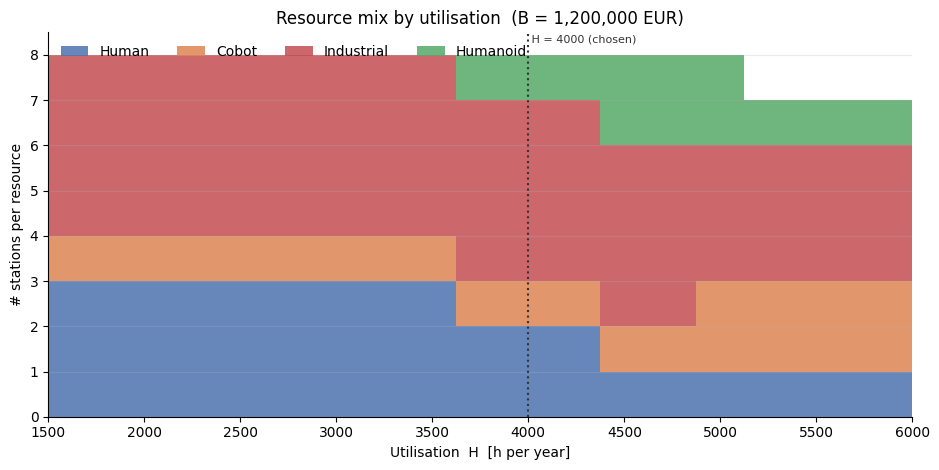

Humanoid in the mix from H = 3,750 h/year.


In [48]:
# ============================================================================
# Resource mix as a function of utilisation H  (budget fixed)
# ============================================================================
B_fix  = int(B_example)                    # fixed budget (adjust if needed)
H_grid = list(range(1500, 6001, 250))      # hours per year
res_H  = [solve_extended(B_fix, Hh=Hh) for Hh in H_grid]

xh       = np.array(H_grid)
counts_H = [[(s["counts"][r] if s["C"] is not None else 0) for s in res_H] for r in range(R)]

fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.set_ylim(0, M + 0.5)
bottom = np.zeros(len(xh))
for r in range(R):
    vals = np.array(counts_H[r])
    ax.fill_between(xh, bottom, bottom + vals, step="mid", color=col[Resources[r]],
                    alpha=0.85, label=Resources[r], linewidth=0)
    bottom = bottom + vals
ax.axvline(H, ls=":", color="#333")
ax.text(H, M + 0.45, f" H = {H} (chosen)", va="top", ha="left", fontsize=8, color="#333")
ax.set_xlabel("Utilisation  H  [h per year]")
ax.set_ylabel("# stations per resource")
ax.set_title(f"Resource mix by utilisation  (B = {B_fix:,} EUR)")
ax.margins(x=0)
ax.legend(frameon=False, ncol=4, loc="upper left")
ax.grid(axis="y", alpha=0.25)
for s in ["top", "right"]: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

# short check: from which utilisation does the first humanoid appear?
hum_idx = Resources.index("Humanoid")
hh = [H_grid[j] for j,s in enumerate(res_H) if s["C"] is not None and s["counts"][hum_idx] > 0]
print(f"Humanoid in the mix from H = {min(hh):,} h/year." if hh else "No humanoid in the considered H range.")